Using device: cpu
Grad-CAM and overlay functions ready.
Model loaded — 10 classes
Grad-CAM initialized.

Valid Images:
 - 0_1.jpg
 - 2_19.jpg
 - t-herpes-zoster-163.jpg


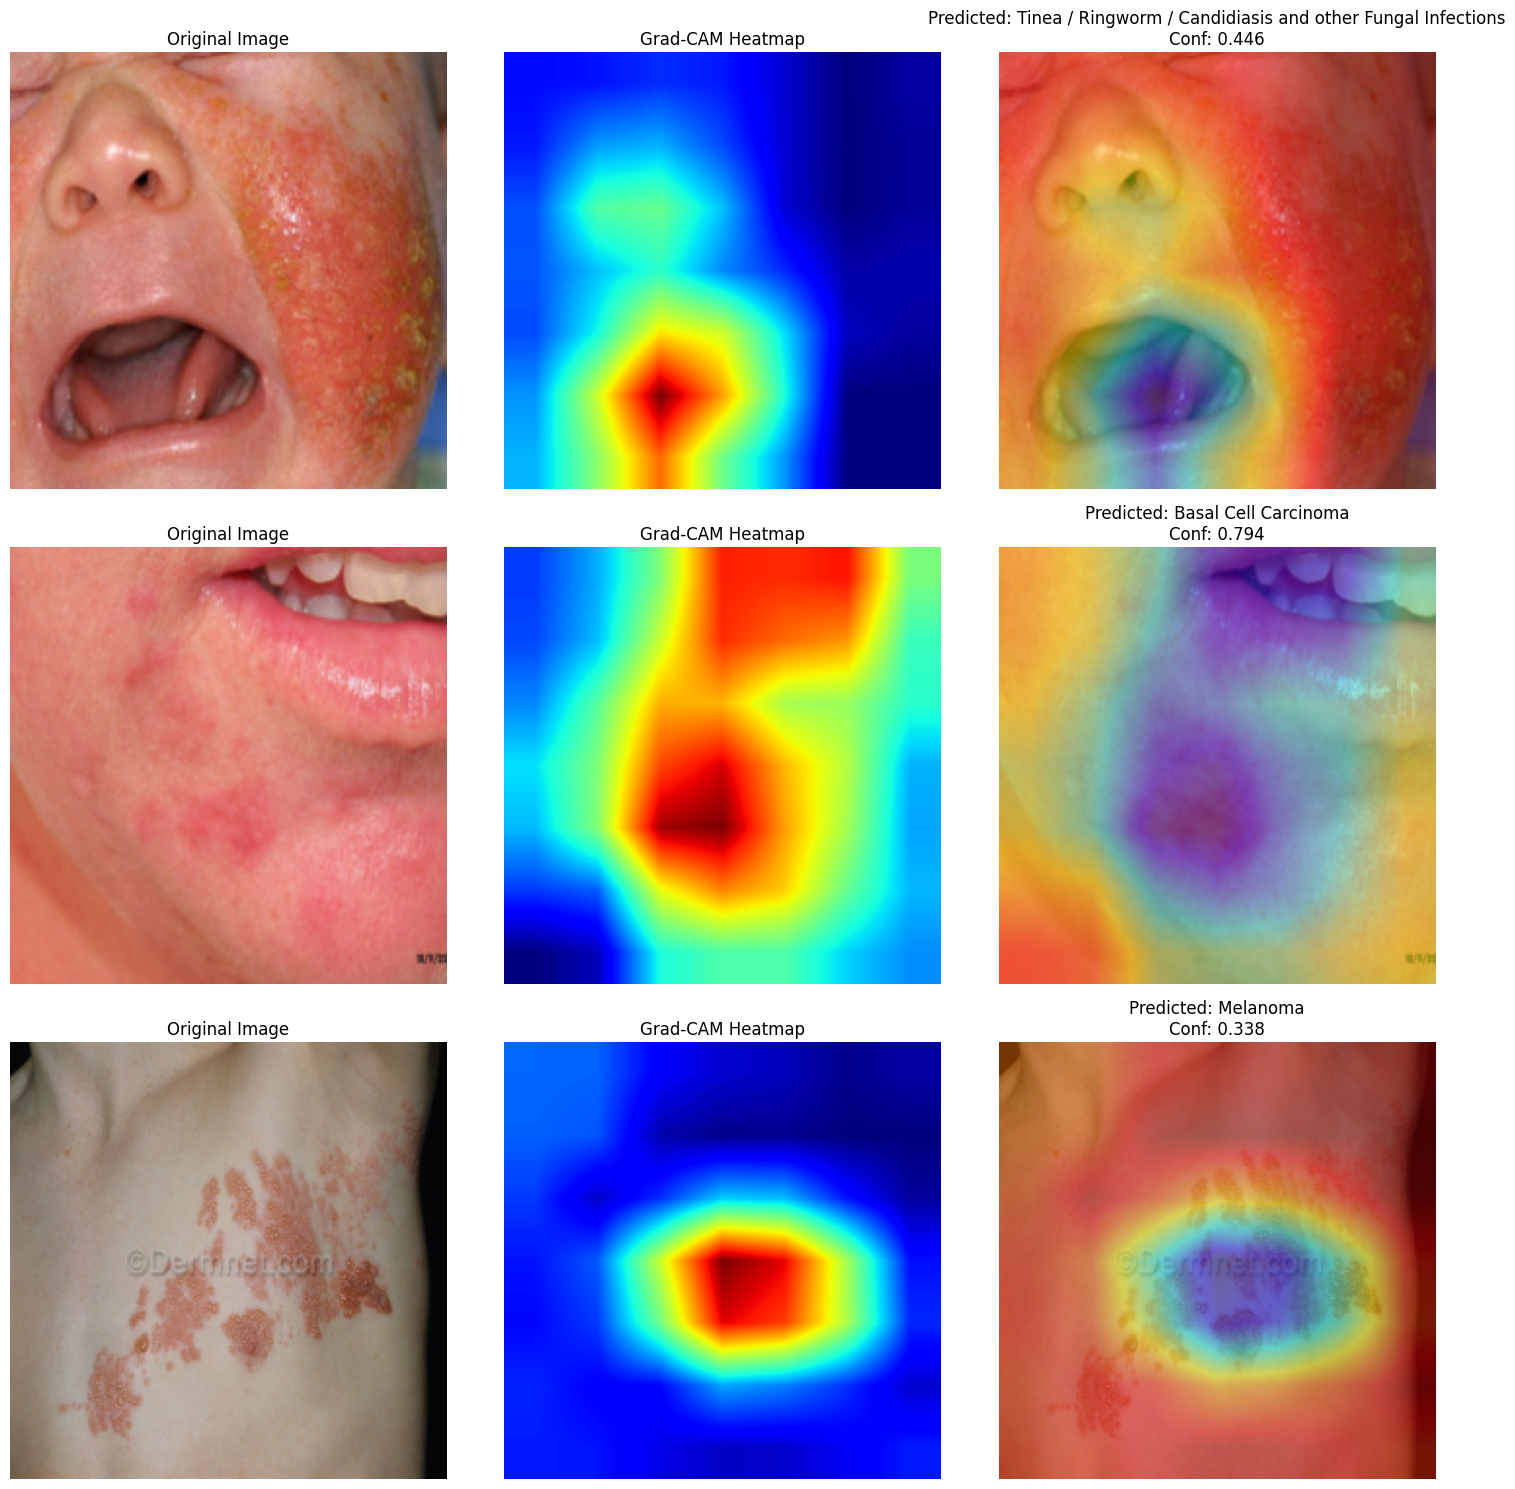

In [1]:
# =============================================================================
#          STEP 23 — Explainable AI with Grad-CAM (FINAL WORKING)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─── Grad-CAM Class ────────────────────────────────────────────────────────────

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def __call__(self, x, class_idx=None):
        self.model.eval()
        logit = self.model(x)
        
        if class_idx is None:
            class_idx = logit.argmax(dim=1).item()
        
        score = logit[:, class_idx].sum()
        self.model.zero_grad()
        score.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        
        cam = cam.squeeze().cpu().numpy()
        cam = np.maximum(cam, 0)

        if cam.max() > 0:
            cam = cam / cam.max()
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx


# ─── Safe Overlay Function (OpenCV 4.8+ Compatible) ──────────────────────────

def overlay_heatmap(image, heatmap, alpha=0.45):

    # Convert to real numpy array
    heatmap = np.array(heatmap)

    # Ensure 2D
    heatmap = np.squeeze(heatmap)

    if heatmap.ndim != 2:
        raise ValueError(f"Heatmap must be 2D. Got {heatmap.shape}")

    # Normalize safely
    heatmap = np.clip(heatmap, 0, 1)

    # Convert to uint8 EXACTLY as OpenCV expects
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)

    # Force contiguous memory (VERY IMPORTANT)
    heatmap_uint8 = np.ascontiguousarray(heatmap_uint8)

    # Apply colormap
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # Resize to match image
    heatmap_color = cv2.resize(
        heatmap_color,
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

    image = np.ascontiguousarray(image.astype(np.uint8))

    overlay = cv2.addWeighted(image, 1 - alpha,
                              heatmap_color, alpha, 0)

    return overlay

print("Grad-CAM and overlay functions ready.")

# ─── Model Loading ─────────────────────────────────────────────────────────────

model_path = "federated_resnet50_skin_model.pth"
checkpoint = torch.load(model_path, map_location=DEVICE)

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_classes = checkpoint.get('num_classes', 10)
model.fc = nn.Linear(model.fc.in_features, num_classes)

state_dict = checkpoint.get('model_state_dict', checkpoint)
new_state_dict = {
    k.replace("model.", "").replace("module.", ""): v
    for k, v in state_dict.items()
    if k.replace("model.", "").replace("module.", "") in model.state_dict()
}

model.load_state_dict(new_state_dict, strict=False)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded — {num_classes} classes")

target_layer = model.layer4[-1].conv3
gradcam = GradCAM(model, target_layer)
print("Grad-CAM initialized.")

# ─── Classes ───────────────────────────────────────────────────────────────────

classes = [
    "Eczema",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma",
    "Melanocytic Nevi (NV)",
    "Benign Keratosis-like Lesions (BKL)",
    "Psoriasis / Lichen Planus and related diseases",
    "Seborrheic Keratoses and other Benign Tumors",
    "Tinea / Ringworm / Candidiasis and other Fungal Infections",
    "Warts / Molluscum and other Viral Infections"
]

# ─── YOUR IMAGE PATHS ADDED HERE ──────────────────────────────────────────────

image_paths = [
    r"Y:\march\new_dev\TK209822 - Federated Learning-Based Skin Disease Detection with Secure Teledermatology for Privacy Preservation\test\1. Eczema 1677\0_1.jpg",
    r"Y:\march\new_dev\TK209822 - Federated Learning-Based Skin Disease Detection with Secure Teledermatology for Privacy Preservation\test\3. Atopic Dermatitis - 1.25k\2_19.jpg",
    r"Y:\march\new_dev\TK209822 - Federated Learning-Based Skin Disease Detection with Secure Teledermatology for Privacy Preservation\test\10. Warts Molluscum and other Viral Infections - 2103\t-herpes-zoster-163.jpg",
]

valid_paths = [p for p in image_paths if os.path.isfile(p)]

if not valid_paths:
    print("No valid image paths found. Please check drive connection.")
    exit()

print("\nValid Images:")
for p in valid_paths:
    print(" -", os.path.basename(p))

# ─── Transform ─────────────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ─── Visualization ─────────────────────────────────────────────────────────────

loaded_tensors = []
for path in valid_paths:
    img_pil = Image.open(path).convert("RGB")
    loaded_tensors.append(transform(img_pil))

images = torch.stack(loaded_tensors).to(DEVICE)
num_samples = len(images)

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
if num_samples == 1:
    axes = np.array([axes])

for i in range(num_samples):

    img_tensor = images[i:i+1]

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = probs.argmax(1).item()
        conf = probs[0, pred_idx].item()

    heatmap, _ = gradcam(img_tensor, class_idx=pred_idx)

    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1) * 255
    img_uint8 = img_np.astype(np.uint8)

    axes[i, 0].imshow(img_uint8)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title("Grad-CAM Heatmap")
    axes[i, 1].axis('off')

    overlay = overlay_heatmap(img_uint8, heatmap)

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f"Predicted: {classes[pred_idx]}\nConf: {conf:.3f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()